In [1]:
import numpy as np # Math
import pandas as pd # Data tables
import matplotlib.pyplot as plt # Plots
import sklearn # Classic ML

Best Estimator: Ridge(alpha=0.001)
s1    -827.70
s5     696.13
bmi    543.84
s2     437.17
bp     346.78
s4     260.76
sex   -241.35
s3     116.95
s6      49.74
age     38.48
dtype: float64


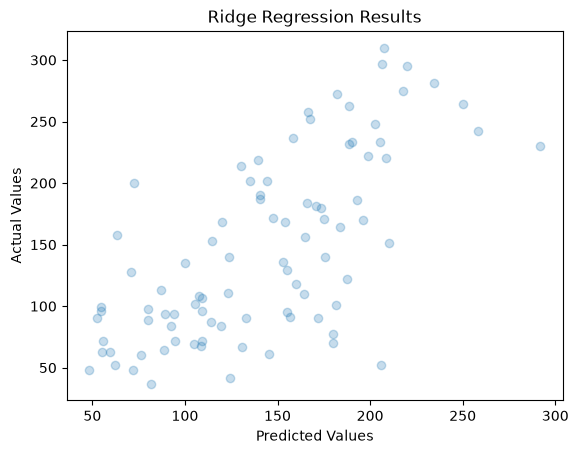

R^2 Score: 0.453428030101933


In [2]:
# Scikit-learn: Linear Ridge Regression

from sklearn.datasets import load_diabetes # load_ means it's part of sci-kit learn package
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.linear_model import Ridge

dataset = load_diabetes(as_frame=True) # as_frame changes the Bunch container to have pandas objects
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.2, random_state=42) # attribute of the 'dataset' Bunch
cross_validation=KFold(n_splits=10, shuffle=True, random_state=42)
ridge_search = GridSearchCV(Ridge(), # find best hyperparameters for ridge model
                            param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, # alpha is regularlization; restrains sensitive weights
                            cv=cross_validation, scoring = 'r2').fit(X_train, y_train)

LRR_model = ridge_search.best_estimator_
print(f"Best Estimator: {LRR_model}")

coefficients = pd.Series(LRR_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False) #Sorts on absolute value of weight magnitude
print(coefficients.round(2))

plt.scatter(LRR_model.predict(X_test), y_test, alpha=0.25)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Ridge Regression Results')
plt.show()

print(f"R^2 Score: {LRR_model.score(X_test, y_test)}")
